# Lab 28 — Multimodal SecureLife: Vision + Text RAG

## A Motor Insurance Claims Agent That Sees and Reads

**Domain:** Insurance (SecureLife — extends Module 6) · **Modalities:** Vision (GPT-4o) + Text RAG (FAISS over policy docs)

The SecureLife agent system you built in Module 6 reviews claims using only structured data (DB queries + 8 SQL tools). But the **real intake** at SecureLife isn't structured: customers upload **photos of vehicle damage** along with their text claim, and adjusters spend hours classifying what they see.

Today we add the missing modality. The agent will look at a damage photo, retrieve the relevant clauses from the customer's policy, cross-check against the existing claim record, and produce a coverage decision — all in one LangGraph pipeline.

## The Business Problem at SecureLife

A typical motor claim arrives like this:

> "Hi, I had a front-end collision at a traffic light on June 14. Other driver admitted fault. Repair estimate is **₹4,35,957**. Attached: photos of the damage. My policy is `POL-2024-0018` (SecureLife Motor Comprehensive). Please process under claim **CLM-2025-0001**."

Today's manual process — adjuster reviews photo, looks up policy, cross-checks the DB claim record — takes **30–45 min per claim**. SecureLife handles **~3,000 claims/month**.

We're going to build the agent version: **photo + policy → coverage decision** in seconds, with the same structured output the adjuster would produce.

## What's NEW in Lab 28 (vs the rest of the SecureLife labs)

> - **NEW:** Vision modality — `gpt-4o` analyses vehicle damage photos via the `image_url` content block API
> - **NEW:** Text RAG — FAISS vector store over the **SecureLife Motor Comprehensive policy document** so the agent grounds decisions in citable policy clauses
> - **NEW:** Multimodal LangGraph — 3 nodes that fan in vision + RAG findings + DB record, then synthesise a coverage decision
> - **NEW:** Fraud signal — the agent compares the **photo's damage estimate** against the **customer's claimed amount** and flags significant mismatches (a real-world fraud indicator)
> - **Inherits:** SecureLife claims DB schema if available (graceful fallback to inline mock claim)
> - **Time split:** ~60% vision + RAG + graph, ~40% setup and sample data

**Prereq:** None — the lab is self-contained. (If you have `/content/SecureLife_claims.db` from the Module 6 Setup notebook, it'll use real claim records; otherwise it uses a built-in mock.)

## Architecture


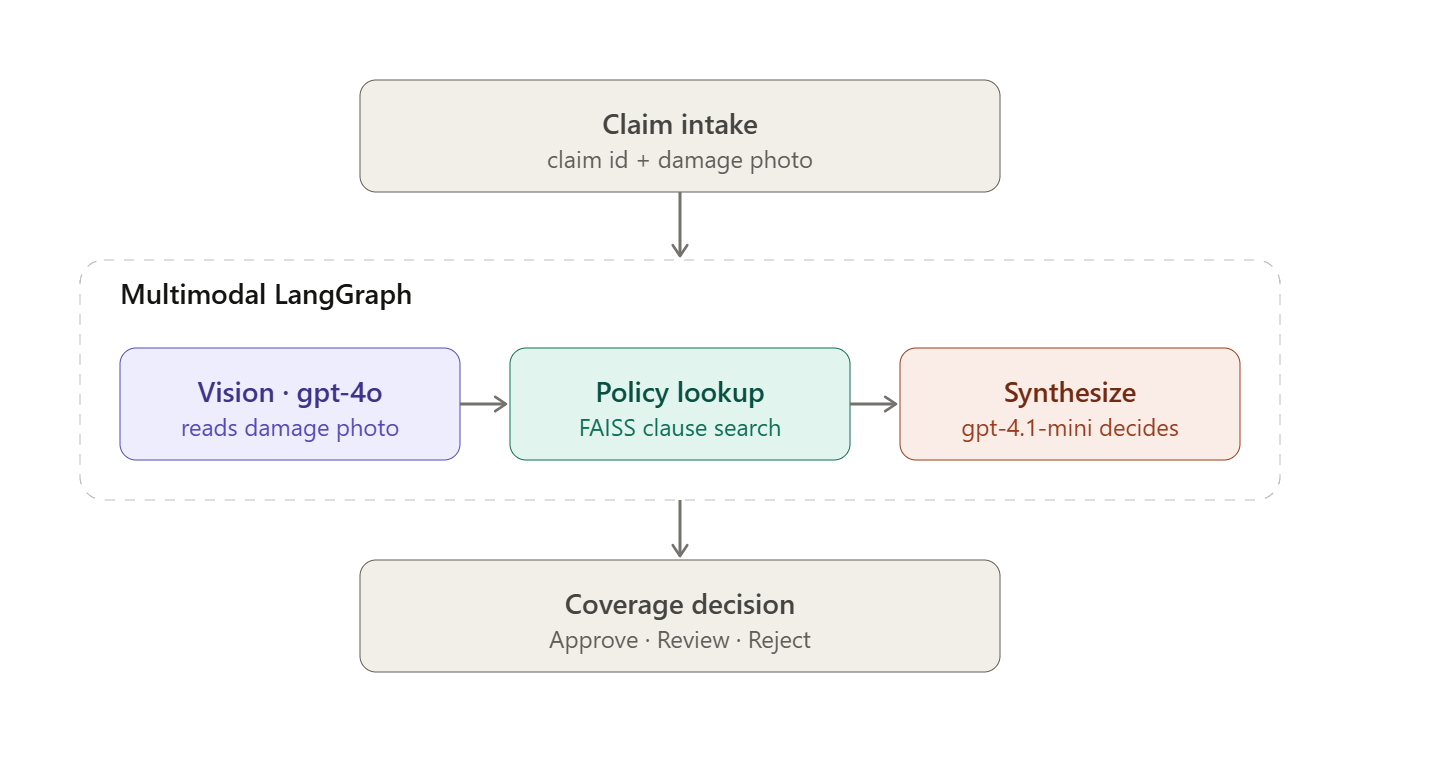

## Section 1 — Setup

In [ ]:
%%capture
# !pip install -q "langchain>=1.0" "langchain-openai>=0.2" "langgraph>=0.2" "langchain-community>=0.3" "faiss-cpu>=1.7" "pillow>=10" "pydantic>=2" "nest-asyncio" "python-dotenv"
!pip install -q langchain langchain-openai langgraph langchain-community faiss-cpu pillow pydantic nest-asyncio


In [ ]:
# --- Imports + API key (Colab/local detection) ---
import os, sys, json, base64, io, sqlite3
from typing import TypedDict, Optional, List
from io import BytesIO

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    ENV = "Colab"
except ImportError:
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    if "OPENAI_API_KEY" not in os.environ:
        raise RuntimeError(
            "OPENAI_API_KEY not found. Set it via Colab Secrets or .env file."
        )
    ENV = "Local"

import nest_asyncio
nest_asyncio.apply()

print(f"✓ Setup complete — environment: {ENV}")


✓ Setup complete — environment: Colab


## Section 2 — Sample Claim Data + Damage Photos

We need two things to feed the agent:

1. **A claim record** — pulled from SecureLife DB if available, otherwise a built-in mock
2. **A vehicle damage photo** — we generate **3 synthetic damage images** with Pillow so the lab runs everywhere with no external image dependencies

> The notebook works even without the SecureLife DB file. If you have `Lab_M6_Setup_SecureLife_DB.ipynb` results on disk, it'll use the real claim; otherwise it falls back to a representative mock claim for CLM-2025-0001 (motor comprehensive, ₹4.35L claim).

In [ ]:
# --- Load the SecureLife claim record ---

def load_claim(claim_id: str) -> dict:
#    """Try the SecureLife DB; fall back to inline mock if unavailable."""
    for db_path in ["/content/SecureLife_claims.db", "SecureLife_claims.db",
                     "../SecureLife_claims.db", "../../SecureLife_claims.db"]:
        if os.path.exists(db_path):
            conn = sqlite3.connect(db_path)
            conn.row_factory = sqlite3.Row
            rows = conn.execute(
                """SELECT c.*, cu.full_name, cu.city,
                          p.policy_id, p.policy_type, p.sum_insured, p.product_name
                   FROM claims c
                   JOIN customers cu ON c.customer_id = cu.customer_id
                   JOIN policies  p  ON c.policy_id   = p.policy_id
                   WHERE c.claim_id = ?""", (claim_id,)).fetchall()
            conn.close()
            if rows:
                print(f"  → loaded {claim_id} from {db_path}")
                return dict(rows[0])
#   print(f"  → DB not found; using MOCK_CLAIM for {claim_id}")
#    return MOCK_CLAIM

claim_record = load_claim("CLM-2025-0001")
print(f"✓ Claim record:")
print(f"  customer:  {claim_record.get('full_name')} ({claim_record.get('city')})")
print(f"  policy:    {claim_record.get('product_name')}")
print(f"  amount:    ₹{claim_record.get('claim_amount'):,}")
print(f"  diagnosis: {claim_record.get('diagnosis')}")


  → loaded CLM-2025-0001 from /content/SecureLife_claims.db
✓ Claim record:
  customer:  Rajesh Sharma (Bengaluru)
  policy:    SecureLife Motor Comprehensive
  amount:    ₹435,957
  diagnosis: Front-end collision damage


In [ ]:
# import the images from /content
img1 = "backside-damage.png"
img2 = "side-damage.jpg"
img3 = "vehicle-damage.jpg"

# convert these images into bytes
with open(img1, "rb") as f:
    img1_bytes = f.read()

with open(img2, "rb") as f:
    img2_bytes = f.read()

with open(img3, "rb") as f:
    img3_bytes = f.read()

# Generate all 3 sample images
SAMPLE_IMAGES = {
    "front_collision": img3_bytes,
    "side_scratch":    img2_bytes,
    "total_loss":      img1_bytes,
}

for k, v in SAMPLE_IMAGES.items():
    print(f"  • {k:18s}  {len(v):>6d} bytes")

  • front_collision     735285 bytes
  • side_scratch        758771 bytes
  • total_loss          662938 bytes



--- FRONT COLLISION ---


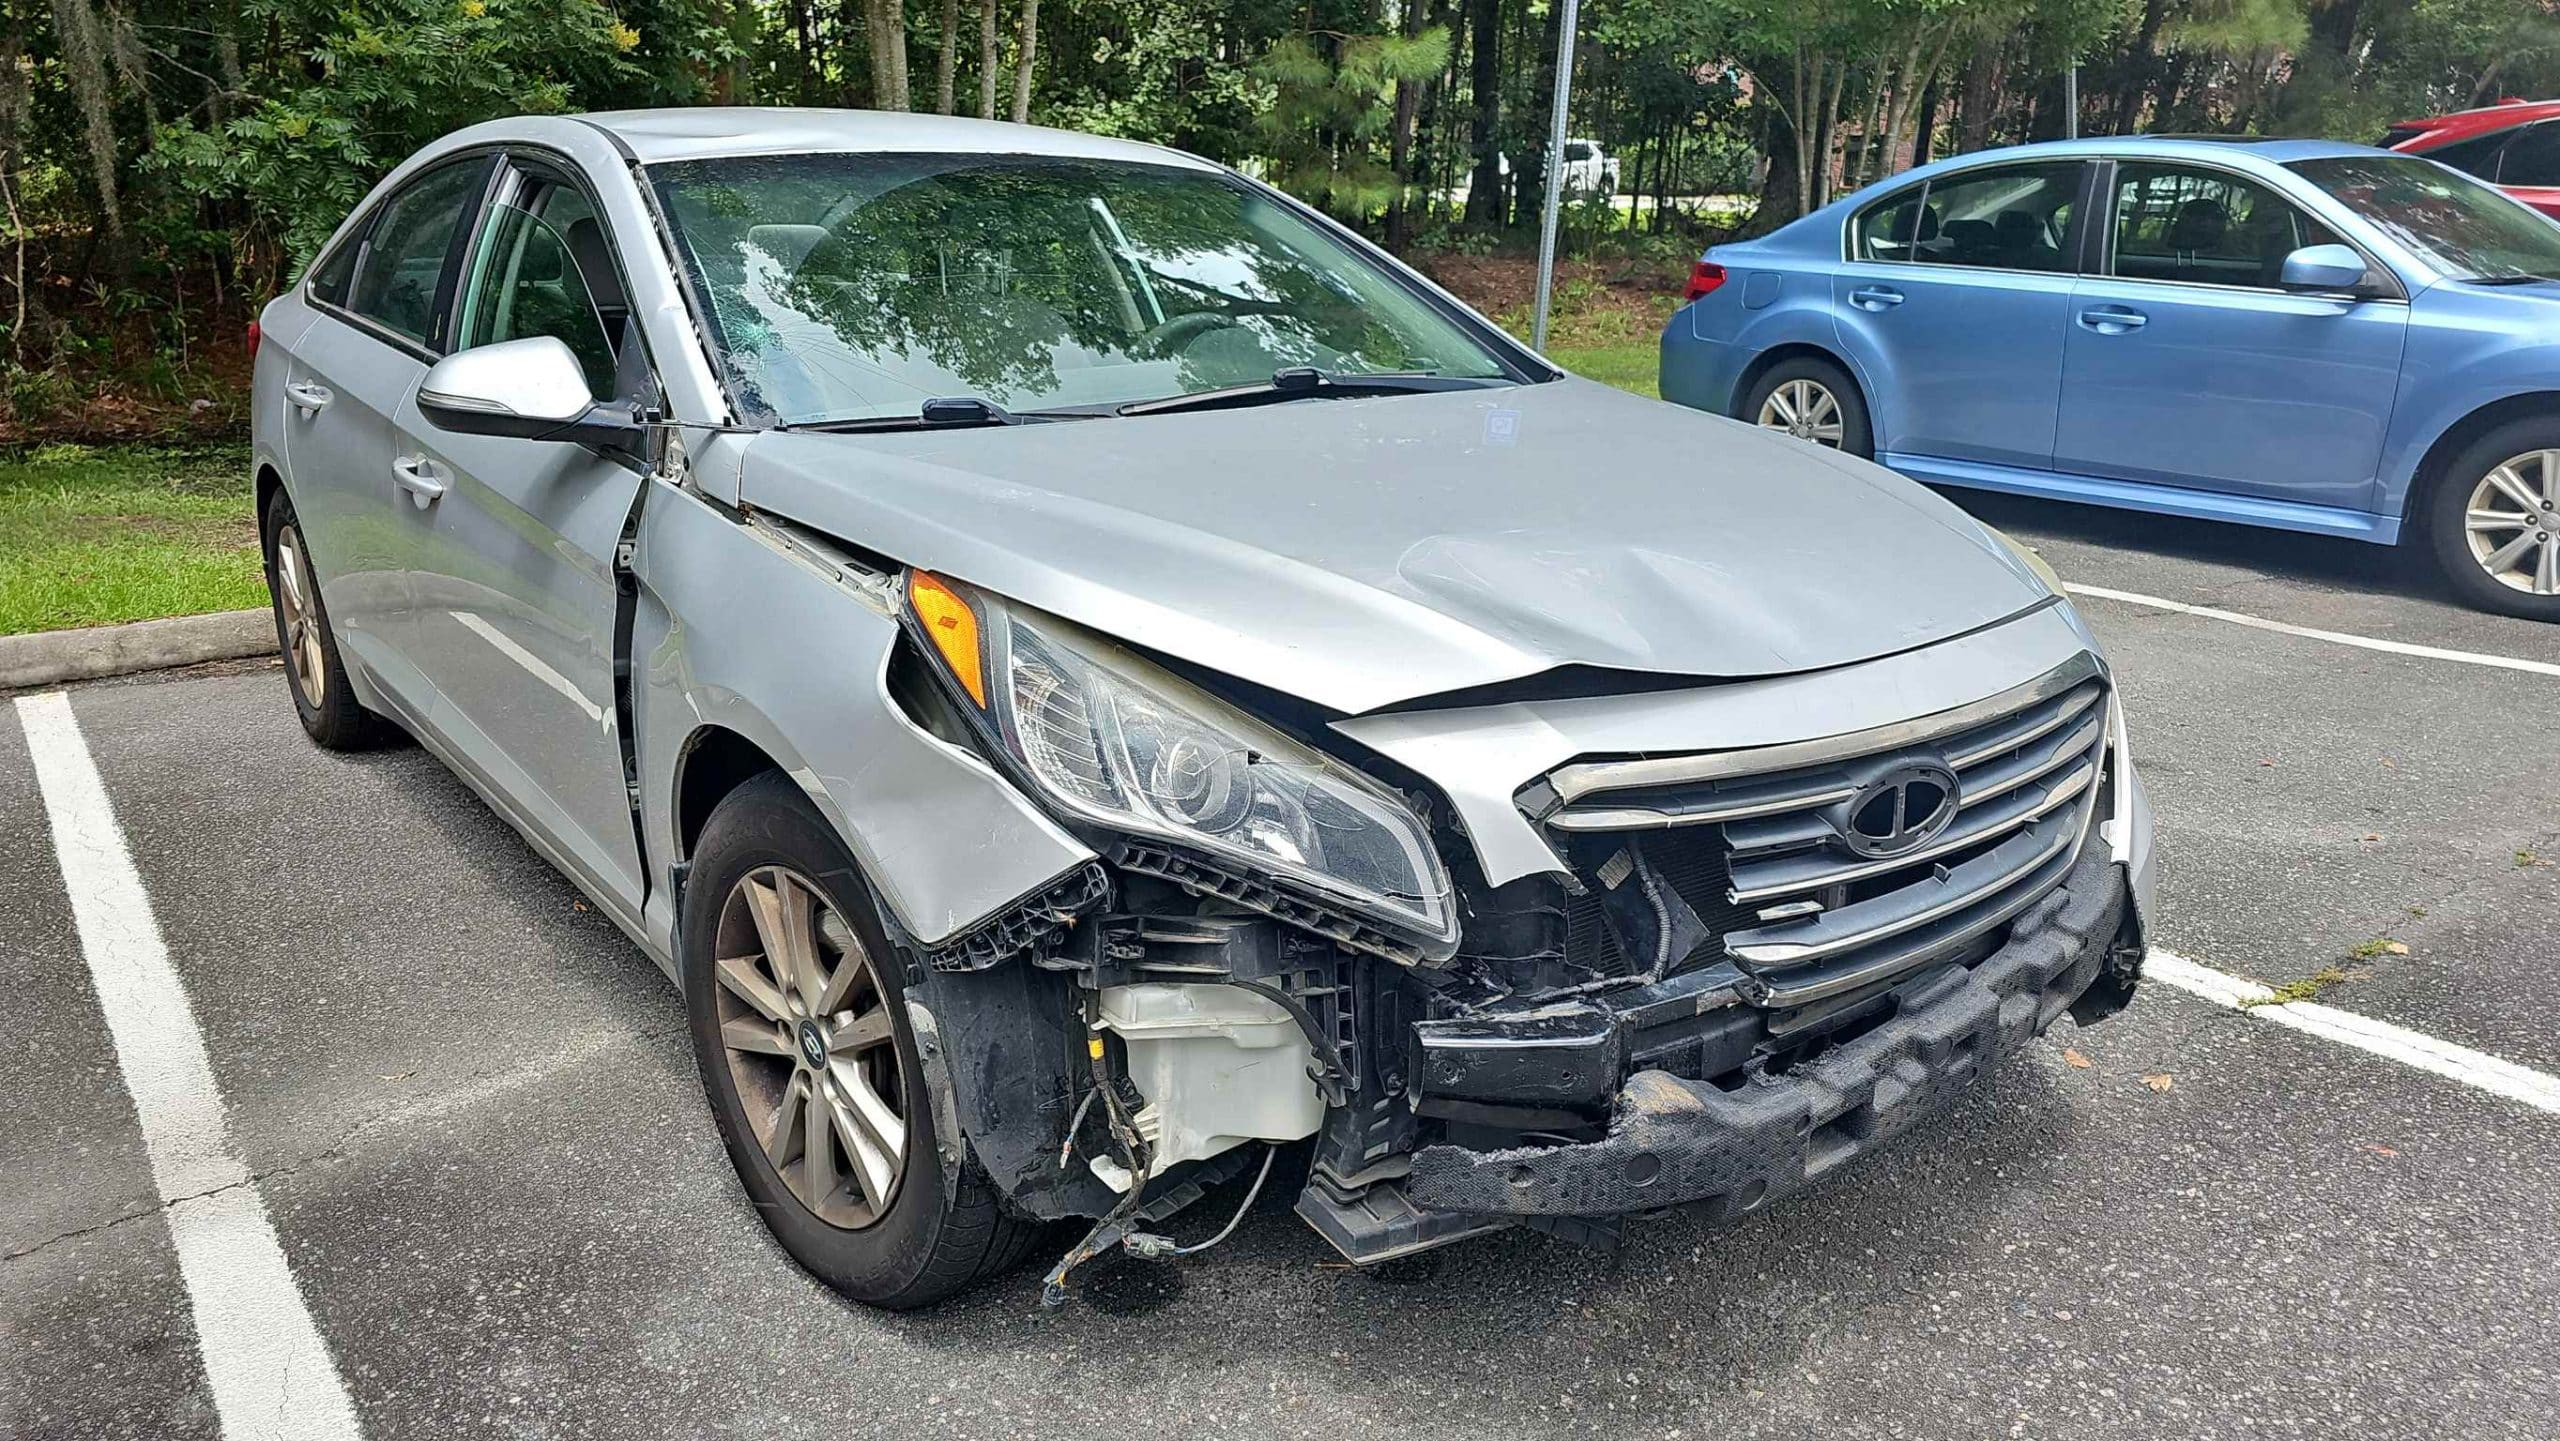


--- SIDE SCRATCH ---


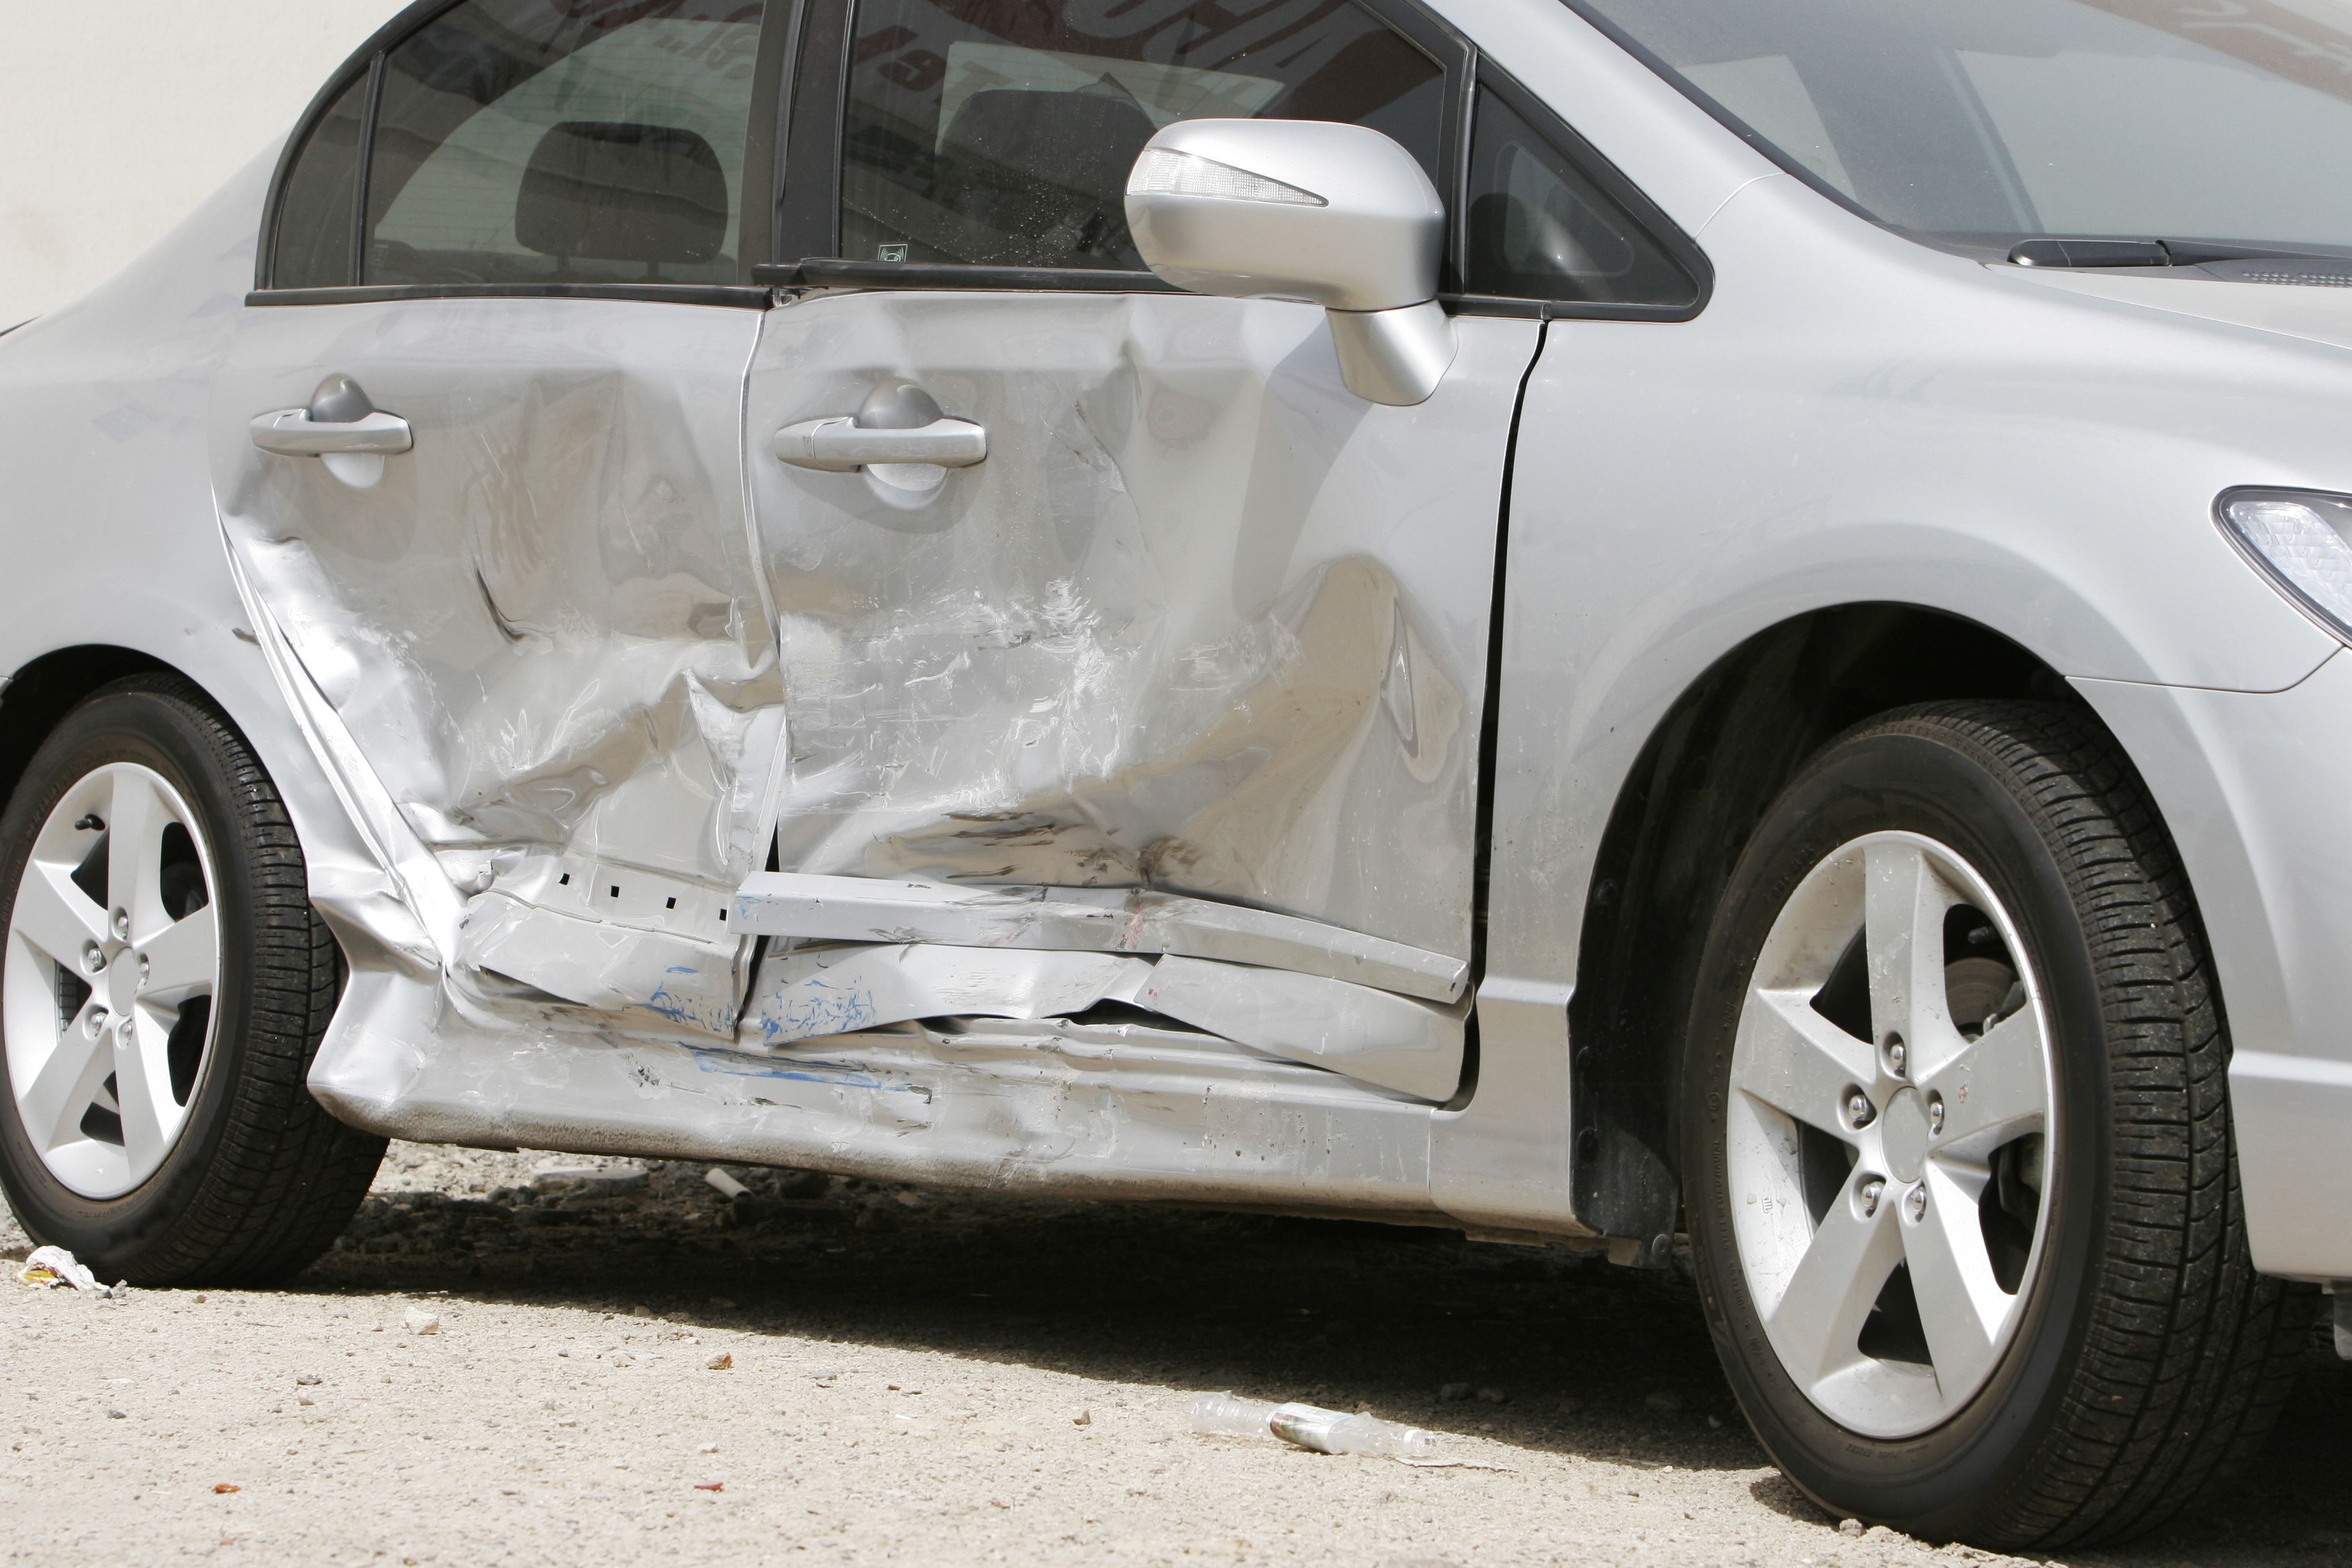


--- TOTAL LOSS ---


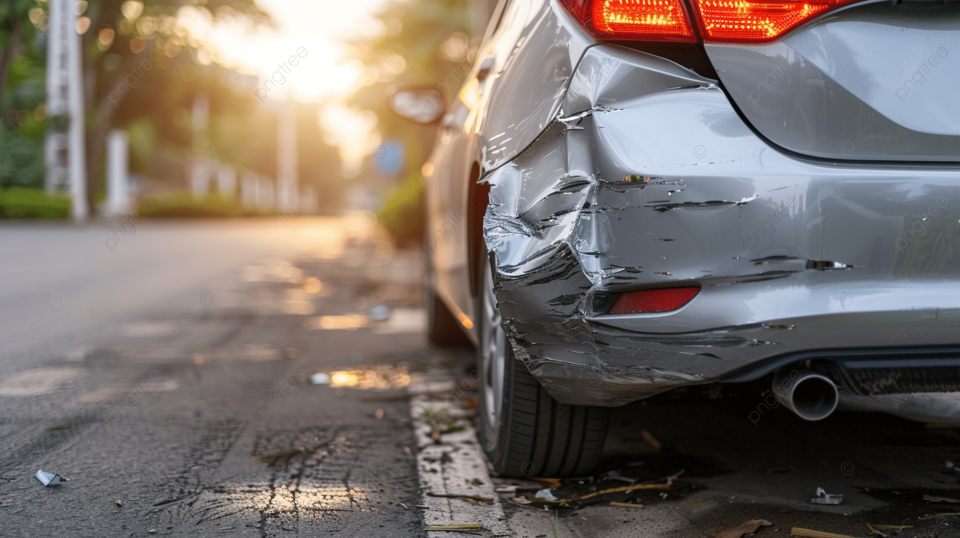


(Synthetic images — they look schematic, but GPT-4o handles real photos identically.
 To use real photos, swap the `image_url` content block in the next section.)


In [ ]:
# --- Display the sample images inline so you can see what GPT-4o will analyse ---
from IPython.display import Image as IPyImage, display
import textwrap

for damage_type, png_bytes in SAMPLE_IMAGES.items():
    print(f"\n--- {damage_type.replace('_', ' ').upper()} ---")
    display(IPyImage(data=png_bytes, format="png", width=320))

print("\n(Synthetic images — they look schematic, but GPT-4o handles real photos identically.")
print(" To use real photos, swap the `image_url` content block in the next section.)")


## Section 3 — Vision Tool (GPT-4o)

The vision tool uses **`gpt-4o`** — OpenAI's flagship multimodal model — through LangChain's `ChatOpenAI`. The trick is the **content block format**: instead of a plain string, the user message becomes a list of blocks, each either text or `image_url`.

### Two ways to pass an image

```python
# 1. As a base64 data URL (what we'll use — keeps everything offline-safe)
{"type": "image_url",
 "image_url": {"url": "data:image/png;base64,<base64string>"}}

# 2. As a public HTTPS URL (no upload, GPT-4o fetches it directly)
{"type": "image_url",
 "image_url": {"url": "https://example.com/damage.jpg"}}
```

The structured output uses Pydantic to force GPT-4o to return JSON with the exact fields we need.

In [ ]:
# --- Define the vision tool ---
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

vision_llm = ChatOpenAI(model="gpt-4o", temperature=0)

class DamageAssessment(BaseModel):
    """Structured output from the vision model."""
    damage_type: str = Field(description=
        "Short label: front_collision | rear_collision | side_panel_scratch | "
        "total_loss | minor_dent | windshield_crack | flood_damage | other")
    severity: int = Field(ge=1, le=10, description=
        "1=cosmetic only, 5=moderate panel work, 10=total loss / unrepairable")
    estimated_repair_inr: int = Field(description=
        "Indian Rupees estimate based on the visible damage. Use realistic ranges: "
        "minor ₹5K-₹30K, moderate ₹30K-₹2L, severe ₹2L-₹6L, total loss > ₹5L")
    parts_affected: List[str] = Field(description=
        "Affected vehicle components, e.g. ['front bumper', 'hood', 'left headlight']")
    confidence: float = Field(ge=0.0, le=1.0, description=
        "How confident the model is in its assessment (1.0 = very confident)")
    summary: str = Field(description=
        "One-sentence description of what's visible in the photo.")

vision_chain = vision_llm.with_structured_output(DamageAssessment)


def analyse_damage_photo(image_bytes: bytes) -> DamageAssessment:
    """Analyse a damage photo and return structured DamageAssessment."""
    b64 = base64.b64encode(image_bytes).decode("ascii")
    data_url = f"data:image/png;base64,{b64}"

    message = {
        "role": "user",
        "content": [
            {"type": "text", "text":
                "You are SecureLife's vehicle damage assessor. Look at this photo "
                "of a damaged vehicle and produce a structured assessment. "
                "Be realistic about INR repair cost estimates for the Indian market."},
            {"type": "image_url", "image_url": {"url": data_url}},
        ],
    }
    return vision_chain.invoke([message])

print("✓ Vision tool defined: analyse_damage_photo(image_bytes) -> DamageAssessment")


✓ Vision tool defined: analyse_damage_photo(image_bytes) -> DamageAssessment


In [ ]:
# --- Test the vision tool on the front-collision image ---
result = analyse_damage_photo(SAMPLE_IMAGES["front_collision"])

print("VISION OUTPUT (front_collision):")
print(f"  damage_type:           {result.damage_type}")
print(f"  severity:              {result.severity}/10")
print(f"  estimated_repair_inr:  ₹{result.estimated_repair_inr:,}")
print(f"  parts_affected:        {result.parts_affected}")
print(f"  confidence:            {result.confidence:.2f}")
print(f"  summary:               {result.summary}")


VISION OUTPUT (front_collision):
  damage_type:           front_collision
  severity:              7/10
  estimated_repair_inr:  ₹250,000
  parts_affected:        ['front bumper', 'hood', 'left headlight', 'left fender', 'grille']
  confidence:            0.95
  summary:               The vehicle has significant front-end damage including the bumper, hood, and left headlight.


## Section 4 — Text Tool: RAG over the SecureLife Motor Policy

The vision tool tells us **what's broken**. The RAG tool tells us **what the policy covers**.

We index the **SecureLife Motor Comprehensive Policy** document (excerpted below — a synthetic but realistic policy covering own-damage, third-party, exclusions, and claim procedure) into a FAISS vector store. The agent will query it semantically — e.g. "Is collision damage covered?" or "What's the deductible for own-damage claims?".

In [ ]:
# --- The SecureLife Motor Comprehensive Policy document (10 clauses) ---
POLICY_CLAUSES = {
    "OD-001_OwnDamageCoverage": (
        "Section A — Own Damage Coverage. SecureLife Motor Comprehensive policy covers "
        "loss or damage to the insured vehicle arising from accident, collision, fire, "
        "theft, malicious acts, natural calamities (flood, earthquake, cyclone), and "
        "transit damage. The maximum coverage equals the Insured's Declared Value (IDV) "
        "as stated on the policy schedule, less applicable depreciation and deductibles."
    ),
    "OD-002_TotalLossDefinition": (
        "A vehicle is declared a constructive total loss (CTL) when the cost of repair "
        "exceeds 75% of the IDV at the time of the accident. In CTL cases, the company "
        "settles the IDV in full less the policyholder's compulsory deductible. The "
        "salvage rights transfer to SecureLife unless otherwise agreed."
    ),
    "OD-003_Deductibles": (
        "Compulsory deductibles apply to every own-damage claim: ₹1,000 for vehicles "
        "below 1500cc engine capacity, ₹2,000 for vehicles 1500cc and above. Voluntary "
        "deductible discounts may apply if elected at policy inception. The deductible "
        "is reduced from the assessed repair cost before settlement."
    ),
    "TP-001_ThirdPartyLiability": (
        "Section B — Third-Party Liability. The policy covers the insured's legal "
        "liability for death or bodily injury to a third party and for property damage, "
        "subject to statutory limits set by the Motor Vehicles Act. Third-party "
        "property damage cover is limited to ₹7,50,000 unless extended."
    ),
    "CL-001_ClaimProcedure": (
        "Section C — Claim Procedure. The insured must notify SecureLife within 48 "
        "hours of the incident. Required documents: filled claim form, original police "
        "FIR (for theft, third-party injury, or accident with damages exceeding "
        "₹50,000), driving licence copy, registration certificate (RC), repair estimate "
        "from an authorised garage, post-repair invoice, and photographs of the damage."
    ),
    "CL-002_AuthorisedGarages": (
        "SecureLife operates a cashless repair facility through its network of authorised "
        "garages. The insured may choose cashless settlement (no upfront payment) at any "
        "network garage, or reimbursement settlement at a non-network garage. Cashless "
        "is recommended for claims above ₹50,000 to avoid liquidity gaps."
    ),
    "EX-001_ExclusionsGeneral": (
        "Exclusions: the policy does NOT cover (a) consequential loss, depreciation, "
        "wear and tear, mechanical or electrical breakdown not arising from a covered "
        "peril; (b) damage while the vehicle is used outside its declared geographical "
        "area; (c) damage occurring while the vehicle is driven by a person without a "
        "valid driving licence; (d) damage caused under the influence of alcohol or "
        "drugs; (e) damage from war, mutiny, nuclear perils, or government-ordered seizure."
    ),
    "EX-002_PreexistingDamage": (
        "Pre-existing damage discovered during inspection is excluded from coverage. "
        "SecureLife reserves the right to compare the post-accident photographs against "
        "the pre-policy survey photographs (taken at policy inception). Claims for "
        "damage not consistent with the reported accident description may be denied "
        "and may trigger SIU (Special Investigation Unit) review."
    ),
    "FR-001_FraudIndicators": (
        "Fraud Indicators triggering SIU review: (a) repair estimate exceeds 70% of "
        "IDV without total-loss declaration; (b) claim amount differs from independent "
        "surveyor estimate by more than 30%; (c) photographs inconsistent with the "
        "stated incident description; (d) multiple claims on the same policy within "
        "12 months; (e) policyholder cannot produce a valid police FIR for high-value "
        "claims."
    ),
    "SET-001_SettlementTimeline": (
        "Settlement timeline: SecureLife will acknowledge the claim within 3 working "
        "days, complete inspection within 7 working days, and communicate the settlement "
        "decision within 30 days of receiving all required documents. Settlements via "
        "NEFT to the policyholder's registered bank account."
    ),
}

print(f"✓ Loaded {len(POLICY_CLAUSES)} policy clauses for RAG indexing")


✓ Loaded 10 policy clauses for RAG indexing


In [ ]:
# --- Build a FAISS vector store over the policy clauses ---
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

policy_docs = [
    Document(page_content=text, metadata={"clause_id": clause_id})
    for clause_id, text in POLICY_CLAUSES.items()
]

policy_vectorstore = FAISS.from_documents(policy_docs, embeddings)

# Quick smoke test
hits = policy_vectorstore.similarity_search(
    "Is front-end collision damage covered?", k=2
)
print(f"✓ Policy vector store ready ({len(policy_docs)} clauses indexed)")
print(f"  Top hit for 'collision damage covered':")
print(f"    {hits[0].metadata['clause_id']}: {hits[0].page_content[:100]}...")


/tmp/ipykernel_3599/1871346696.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


✓ Policy vector store ready (10 clauses indexed)
  Top hit for 'collision damage covered':
    EX-002_PreexistingDamage: Pre-existing damage discovered during inspection is excluded from coverage. SecureLife reserves the ...


In [ ]:
# --- Define the policy_lookup tool ---
def policy_lookup(query: str, k: int = 3) -> list:
    """Semantic search over the SecureLife motor policy.

    Returns top-k clauses with their clause IDs.
    """
    hits = policy_vectorstore.similarity_search(query, k=k)
    return [
        {"clause_id": h.metadata["clause_id"], "text": h.page_content}
        for h in hits
    ]

# Test it
clauses = policy_lookup("What is the deductible for a 1200cc car?", k=2)
print(f"✓ policy_lookup tool ready")
for c in clauses:
    print(f"  {c['clause_id']}: {c['text'][:90]}...")


✓ policy_lookup tool ready
  OD-003_Deductibles: Compulsory deductibles apply to every own-damage claim: ₹1,000 for vehicles below 1500cc e...
  TP-001_ThirdPartyLiability: Section B — Third-Party Liability. The policy covers the insured's legal liability for dea...


## Section 5 — The Combined Multimodal Agent

We assemble a 3-node LangGraph:

| Node | Reads from state | Writes to state | LLM |
|------|-----------------|-----------------|-----|
| `vision_node` | `image_bytes` | `damage_assessment` (DamageAssessment) | gpt-4o |
| `policy_node` | `damage_assessment` | `policy_citations` (list) | embeddings only |
| `synthesize_node` | all of the above + claim_record | `decision` (CoverageDecision) | gpt-4.1-mini |

The synthesize node is where the **fraud signal** is computed: if the vision's `estimated_repair_inr` differs from the customer's `claim_amount` by more than 30%, we flag it per policy clause `FR-001_FraudIndicators`.

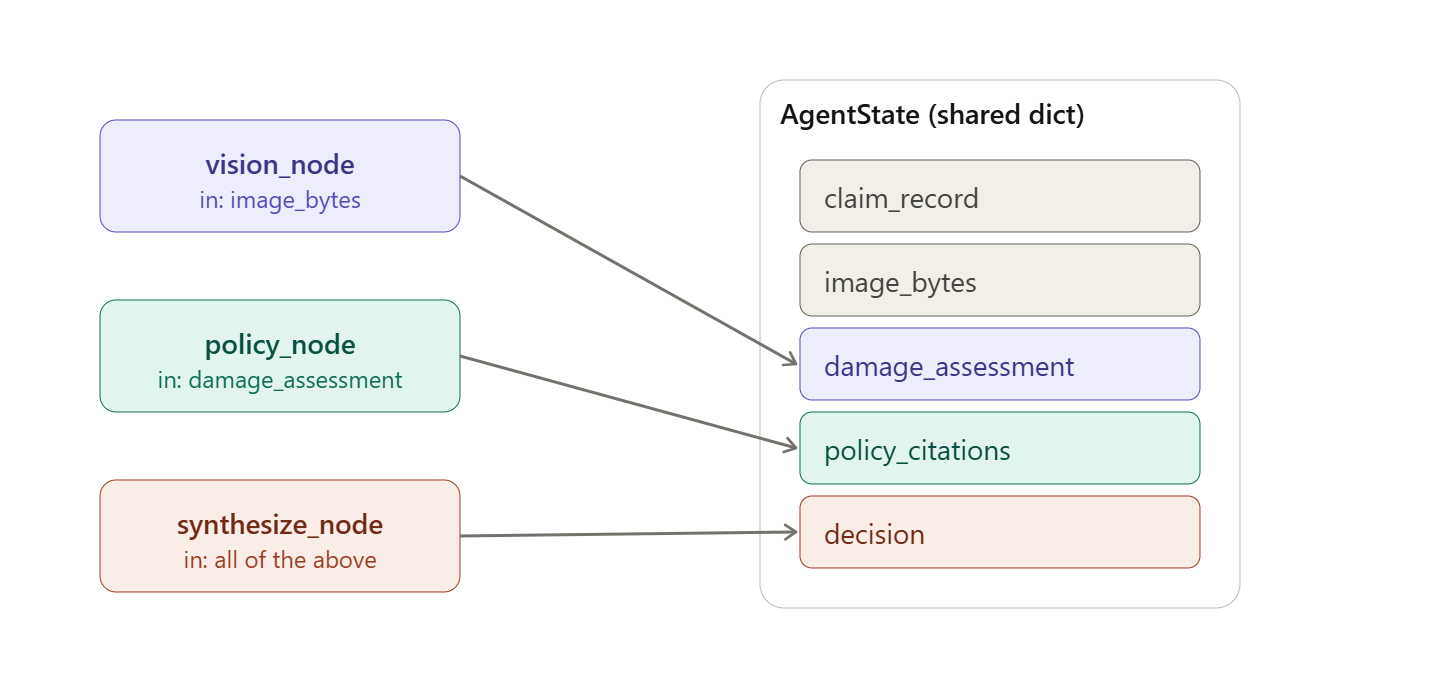

In [ ]:
# --- Shared graph state ---
from typing import TypedDict, Optional, List
from langgraph.graph import StateGraph, END

class AgentState(TypedDict, total=False):
    # Inputs
    claim_record: dict
    image_bytes: bytes
    # Filled by vision_node
    damage_assessment: dict   # DamageAssessment as dict
    # Filled by policy_node
    policy_citations: List[dict]
    # Filled by synthesize_node
    decision: dict

print("✓ AgentState defined (TypedDict)")


✓ AgentState defined (TypedDict)


In [ ]:
# --- Node 1: vision_node (uses analyse_damage_photo from Section 3) ---
def vision_node(state: AgentState) -> dict:
    result = analyse_damage_photo(state["image_bytes"])
    return {"damage_assessment": result.model_dump()}

# --- Node 2: policy_node (semantic search based on the damage type) ---
def policy_node(state: AgentState) -> dict:
    damage = state["damage_assessment"]
    queries = [
        f"Is {damage['damage_type']} covered under own damage?",
        "What deductible applies for a motor own-damage claim?",
        "When is a vehicle declared a total loss?",
        "What documents are required for a claim?",
    ]
    seen = set()
    citations = []
    for q in queries:
        for hit in policy_lookup(q, k=2):
            if hit["clause_id"] not in seen:
                seen.add(hit["clause_id"])
                citations.append(hit)
    return {"policy_citations": citations}

print("✓ vision_node + policy_node defined")


✓ vision_node + policy_node defined


In [ ]:
# --- Node 3: synthesize_node (final coverage decision) ---
from langchain_core.prompts import ChatPromptTemplate

synthesizer_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

class CoverageDecision(BaseModel):
    decision: str = Field(description="APPROVE | REVIEW | REJECT")
    confidence: float = Field(ge=0.0, le=1.0)
    estimated_repair_inr: int
    claimed_amount_inr: int
    fraud_signal: bool = Field(description=
        "True if photo damage is inconsistent with claimed amount by >30%, "
        "or if other policy FR-001 indicators apply")
    fraud_signal_reason: str
    coverage_clause_ids: List[str] = Field(description=
        "Policy clauses supporting the coverage decision (from policy_citations)")
    reasoning: str = Field(description="2-3 sentence explanation")
    next_steps: str = Field(description="What the adjuster should do next")

synth_chain = synthesizer_llm.with_structured_output(CoverageDecision)

SYNTH_PROMPT = ChatPromptTemplate.from_template(
    "You are SecureLife's claims adjudication assistant. Make a coverage decision "
    "by cross-checking the visual damage assessment against the customer's claim "
    "and the policy clauses.\n\n"
    "Decision rules:\n"
    "  - APPROVE: damage consistent with claim, total covered amount ≤ sum insured\n"
    "  - REVIEW: any fraud signal triggered, OR ambiguity in damage vs claim\n"
    "  - REJECT: damage type explicitly excluded (see EX-001), or pre-existing damage signs\n\n"
    "Fraud check (per clause FR-001):\n"
    "  - flag if |estimated_repair - claimed_amount| / claimed_amount > 0.30\n"
    "  - flag if estimated_repair > 70% of sum_insured without total-loss declaration\n\n"
    "Claim record:\n{claim_record}\n\n"
    "Vision assessment:\n{damage_assessment}\n\n"
    "Policy clauses retrieved (cite the relevant ones in your decision):\n"
    "{policy_citations}\n"
)

def synthesize_node(state: AgentState) -> dict:
    rendered = SYNTH_PROMPT.format_messages(
        claim_record=json.dumps(state["claim_record"], indent=2),
        damage_assessment=json.dumps(state["damage_assessment"], indent=2),
        policy_citations="\n".join(
            f"- [{c['clause_id']}] {c['text'][:200]}..." for c in state["policy_citations"]
        ),
    )
    decision = synth_chain.invoke(rendered)
    return {"decision": decision.model_dump()}

print("✓ synthesize_node defined")


✓ synthesize_node defined


In [ ]:
# --- Build and compile the graph ---
graph = StateGraph(AgentState)
graph.add_node("vision",       vision_node)
graph.add_node("policy",       policy_node)
graph.add_node("synthesize",   synthesize_node)
graph.set_entry_point("vision")
graph.add_edge("vision",     "policy")
graph.add_edge("policy",     "synthesize")
graph.add_edge("synthesize", END)
multimodal_agent = graph.compile()

print("✓ Graph compiled: vision → policy → synthesize → END")


✓ Graph compiled: vision → policy → synthesize → END


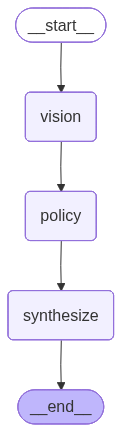

In [ ]:
# --- Visualise the graph ---
try:
    from IPython.display import Image as IPyImage, display
    display(IPyImage(multimodal_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Mermaid render skipped: {e})")
    print(multimodal_agent.get_graph().draw_ascii())


## Section 6 — Run on Sample Claims

We run the pipeline on all 3 damage scenarios against the same claim record (CLM-2025-0001, claimed amount ₹4,35,957). Expected behaviour:

| Image | Likely vision estimate | Expected decision |
|-------|------------------------|-------------------|
| `front_collision` | Moderate (₹2L-₹5L) | **APPROVE** — consistent with claim |
| `side_scratch` | Low (₹15K-₹40K) | **REVIEW** — large mismatch flags fraud signal (claim ₹4.35L >> ₹40K estimate) |
| `total_loss` | High (₹5L+) | **REVIEW** — likely exceeds 70% IDV threshold (sum insured ₹5L), triggers total-loss assessment |

This is real fraud-detection logic — adjusters apply exactly this reasoning.

In [ ]:
# --- Run the pipeline on each sample image ---

def pretty_print_decision(label: str, final_state: dict) -> None:
    d = final_state["decision"]
    va = final_state["damage_assessment"]
    print(f"\n{'='*70}")
    print(f"  CLAIM: {final_state['claim_record']['claim_id']}  |  IMAGE: {label}")
    print(f"{'='*70}")
    print(f"  VISION:")
    print(f"    type:                 {va['damage_type']}")
    print(f"    severity:             {va['severity']}/10")
    print(f"    estimated_repair_inr: ₹{va['estimated_repair_inr']:,}")
    print(f"    parts:                {', '.join(va['parts_affected'])}")
    print(f"  DECISION:")
    print(f"    action:               {d['decision']}")
    print(f"    confidence:           {d['confidence']:.2f}")
    print(f"    claimed:              ₹{d['claimed_amount_inr']:,}")
    print(f"    estimated:            ₹{d['estimated_repair_inr']:,}")
    print(f"    fraud signal:         {d['fraud_signal']}  ({d['fraud_signal_reason']})")
    print(f"    cited clauses:        {', '.join(d['coverage_clause_ids'])}")
    print(f"  REASONING:")
    for line in d['reasoning'].split('. '):
        if line.strip():
            print(f"    • {line.strip()}.")
    print(f"  NEXT STEPS:")
    print(f"    {d['next_steps']}")

results = {}
for damage_type, png_bytes in SAMPLE_IMAGES.items():
    final = multimodal_agent.invoke({
        "claim_record": claim_record,
        "image_bytes": png_bytes,
    })
    results[damage_type] = final
    pretty_print_decision(damage_type, final)



  CLAIM: CLM-2025-0001  |  IMAGE: front_collision
  VISION:
    type:                 front_collision
    severity:             7/10
    estimated_repair_inr: ₹250,000
    parts:                front bumper, hood, left headlight, left fender, grille
  DECISION:
    action:               APPROVE
    confidence:           0.95
    claimed:              ₹435,957
    estimated:            ₹250,000
    fraud signal:         True  (Claimed amount (₹435,957) exceeds estimated repair cost (₹250,000) by more than 30%, triggering fraud signal per FR-001. However, estimated repair cost is only 50% of sum insured (₹500,000), below 70% threshold for total loss.)
    cited clauses:        OD-001_OwnDamageCoverage, FR-001_FraudIndicators
  REASONING:
    • The visual damage assessment shows significant front-end damage consistent with the claim diagnosis.
    • The estimated repair cost (₹250,000) is less than the claimed amount (₹435,957) by more than 30%, triggering a fraud signal per clause FR-00

In [ ]:
# --- Summary table across the 3 scenarios ---
import pandas as pd

rows = []
for damage_type, final in results.items():
    d = final["decision"]
    va = final["damage_assessment"]
    rows.append({
        "scenario":    damage_type,
        "vision_type": va["damage_type"],
        "severity":    va["severity"],
        "est_₹":       f"₹{va['estimated_repair_inr']:,}",
        "claimed_₹":   f"₹{d['claimed_amount_inr']:,}",
        "decision":    d["decision"],
        "fraud":       "FLAG" if d["fraud_signal"] else "—",
        "conf":        f"{d['confidence']:.2f}",
    })

print("\nSUMMARY — 3 scenarios on the SAME claim (CLM-2025-0001, claimed ₹4,35,957):\n")
print(pd.DataFrame(rows).to_string(index=False))



SUMMARY — 3 scenarios on the SAME claim (CLM-2025-0001, claimed ₹4,35,957):

       scenario        vision_type  severity    est_₹ claimed_₹ decision fraud conf
front_collision    front_collision         7 ₹250,000  ₹435,957  APPROVE  FLAG 0.95
   side_scratch side_panel_scratch         5 ₹120,000  ₹435,957   REVIEW  FLAG 0.90
     total_loss     rear_collision         5  ₹50,000  ₹435,957   REJECT  FLAG 0.95


## Section 7 — Production Path + Recap

### Production path: from this notebook to real claims at scale

| Notebook today | Real production deployment |
|----------------|---------------------------|
| Synthetic damage images (Pillow) | Real customer photos uploaded via the SecureLife mobile app → S3 bucket |
| `analyse_damage_photo(bytes)` | Lambda triggered on S3 upload, calls GPT-4o, writes result to DynamoDB |
| Inline policy text | RAG over the **full policy registry** (every SecureLife product variant) |
| Mock or DB-loaded claim | Real claim from the SecureLife claims DB via the **MCP server** (Module 6) |
| Single-shot decision | Decision feeds into the **5-node LangGraph review pipeline** (Lab 24 v2) → human adjuster gets a pre-filled recommendation |

The agent code itself doesn't change — only the I/O layer.

### Recap — what you built

- **Vision-grounded claims agent**: GPT-4o looks at vehicle damage and produces structured assessments
- **Text-grounded RAG**: FAISS vector store over the SecureLife Motor Comprehensive policy
- **Multimodal LangGraph**: 3 nodes that compose vision + RAG + DB record into one coverage decision
- **Real fraud heuristic**: cross-check photo damage estimate against claimed amount; flag mismatches per policy `FR-001`
- **Structured output everywhere**: Pydantic schemas for both vision assessment and final decision

### Key takeaways

1. **Multimodal in LangChain is just another content block.** No new framework, no separate API — `image_url` slots into the same message you'd send with text.
2. **GPT-4o + structured output** = adjuster-ready JSON, not free-form descriptions. The `with_structured_output(Schema)` pattern is the multiplier.
3. **RAG + vision + structured DB record** is the production claims pattern. Each modality answers a different part of "should we pay this claim?"
4. **The fraud signal is a 4-line check** — `|est - claimed| / claimed > 0.30`. Most production fraud heuristics are this simple; the value is in **applying** them consistently.

### Where this fits in the SecureLife arc

| Module | Capability you added |
|--------|---------------------|
| Module 6 (Labs 21-24v2) | Guardrails, observability, **MCP server with 8 SQL tools**, multi-agent review graph with persistence |
| Module 6 (Lab 25 + securelife_client_app) | Production MCP server-client, FastAPI service, Chainlit chat UI |
| Module 7 (Lab 27) | Comparison framework: same compliance pipeline in **Google ADK** vs LangGraph |
| **Module 7 (Lab 28 — this lab)** | **Multimodal vision + text RAG** layered on top of the SecureLife agent |

**SecureLife is now a complete agentic insurance system** — structured DB, MCP layer, REST/chat/CLI consumers, multi-step review, multimodal intake, and a production deployment path.

**End of Module 7 lab series.**